In [1]:
from Finance.Portfolio_optimization_binary import PortfolioOptimization_Binary

In [2]:
import numpy as np

In [3]:
#Defining parameters
n = 5  # number of assets

mu = np.array([0.10, 0.12, 0.07, 0.09, 0.11])

Sigma = np.array([
    [0.10, 0.02, 0.01, 0.03, 0.02],
    [0.02, 0.08, 0.02, 0.01, 0.03],
    [0.01, 0.02, 0.09, 0.02, 0.01],
    [0.03, 0.01, 0.02, 0.07, 0.02],
    [0.02, 0.03, 0.01, 0.02, 0.06]
])

K = 3
lam = 1.0
P = 10.0

In [4]:
#Creating the portfolio optimization problem
PFO_test = PortfolioOptimization_Binary(n= mu.size, mu=mu, Sigma=Sigma, lam=lam)

In [5]:
# Adding Budget Constraint
PFO_test.add_budget_constraint(P,K)

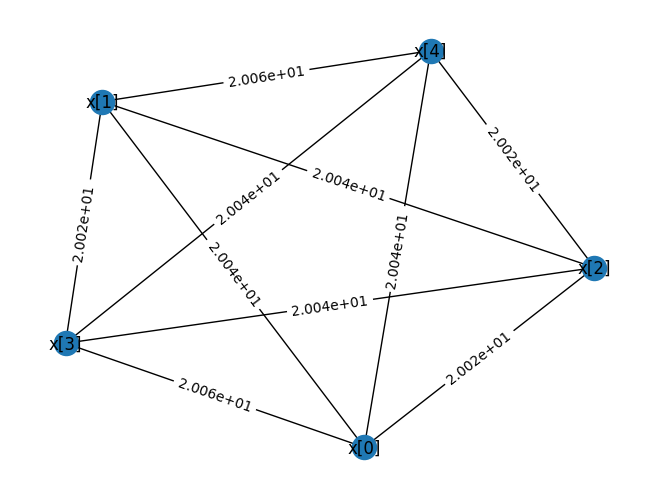

In [6]:
Graph = PFO_test.build_graph()

In [7]:
H_qiskit = PFO_test.build_hamiltonian(eco='Qiskit', offset_incl=False)
print(H_qiskit)

SparsePauliOp(['ZIIII', 'IZIII', 'IIZII', 'IIIZI', 'IIIIZ', 'IZIZI', 'ZZIII', 'IIZZI', 'ZIZII', 'ZIIZI', 'ZIIIZ', 'IZZII', 'IZIIZ', 'IIZIZ', 'IIIZZ'],
              coeffs=[-4.96 +0.j, -4.98 +0.j, -4.96 +0.j, -4.97 +0.j, -4.985+0.j,  5.005+0.j,
  5.01 +0.j,  5.01 +0.j,  5.005+0.j,  5.015+0.j,  5.01 +0.j,  5.01 +0.j,
  5.015+0.j,  5.005+0.j,  5.01 +0.j])


In [8]:
H_pennylane = PFO_test.build_hamiltonian(eco='PennyLane')
print(H_pennylane)

-4.960000000000001 * Z(0) + -4.98 * Z(1) + -4.959999999999997 * Z(2) + -4.970000000000002 * Z(3) + -4.984999999999999 * Z(4) + 5.005000000000001 * (Z(1) @ Z(3)) + 5.01 * (Z(0) @ Z(1)) + 5.01 * (Z(2) @ Z(3)) + 5.005000000000001 * (Z(0) @ Z(2)) + 5.015000000000001 * (Z(0) @ Z(3)) + 5.01 * (Z(0) @ Z(4)) + 5.01 * (Z(1) @ Z(2)) + 5.015000000000001 * (Z(1) @ Z(4)) + 5.005000000000001 * (Z(2) @ Z(4)) + 5.01 * (Z(3) @ Z(4)) + 15.050000000000011 * I(0)


In [9]:
H_cirq = PFO_test.build_hamiltonian(eco='Cirq')
print(H_cirq)

[((-4.960000000000001+0j)*cirq.Z(cirq.LineQubit(0))), ((-4.98+0j)*cirq.Z(cirq.LineQubit(1))), ((-4.959999999999997+0j)*cirq.Z(cirq.LineQubit(2))), ((-4.970000000000002+0j)*cirq.Z(cirq.LineQubit(3))), ((-4.984999999999999+0j)*cirq.Z(cirq.LineQubit(4))), ((5.005000000000001+0j)*cirq.Z(cirq.LineQubit(1))*cirq.Z(cirq.LineQubit(3))), ((5.01+0j)*cirq.Z(cirq.LineQubit(0))*cirq.Z(cirq.LineQubit(1))), ((5.01+0j)*cirq.Z(cirq.LineQubit(2))*cirq.Z(cirq.LineQubit(3))), ((5.005000000000001+0j)*cirq.Z(cirq.LineQubit(0))*cirq.Z(cirq.LineQubit(2))), ((5.015000000000001+0j)*cirq.Z(cirq.LineQubit(0))*cirq.Z(cirq.LineQubit(3))), ((5.01+0j)*cirq.Z(cirq.LineQubit(0))*cirq.Z(cirq.LineQubit(4))), ((5.01+0j)*cirq.Z(cirq.LineQubit(1))*cirq.Z(cirq.LineQubit(2))), ((5.015000000000001+0j)*cirq.Z(cirq.LineQubit(1))*cirq.Z(cirq.LineQubit(4))), ((5.005000000000001+0j)*cirq.Z(cirq.LineQubit(2))*cirq.Z(cirq.LineQubit(4))), ((5.01+0j)*cirq.Z(cirq.LineQubit(3))*cirq.Z(cirq.LineQubit(4))), ((15.050000000000011+0j)*cirq.Pa

In [8]:
p=3
Solve_test = PFO_test.solver(p)

Step 0: Energy = 32.04921953457539
Step 10: Energy = 15.57974394088403
Step 20: Energy = -0.5364570963873674
Step 30: Energy = -8.135282737145356
Step 40: Energy = -10.906287680389621
Step 50: Energy = -10.999340957137278
Step 60: Energy = -11.562708133729123
Step 70: Energy = -11.903607586228718
Step 80: Energy = -12.313692381410712
Step 90: Energy = -12.413207230460515


In [9]:
Solve_test

{'gammas_opt': tensor([ 0.60121592, -0.58030874,  0.28838897], requires_grad=True),
 'betas_opt': tensor([0.89507896, 0.11962838, 0.55319361], requires_grad=True),
 'energy': tensor(-12.43847481, requires_grad=True),
 'history': [tensor(32.04921953, requires_grad=True),
  tensor(9.52824976, requires_grad=True),
  tensor(-1.20267125, requires_grad=True),
  tensor(-5.45990076, requires_grad=True),
  tensor(13.67426362, requires_grad=True),
  tensor(29.28603205, requires_grad=True),
  tensor(18.13454349, requires_grad=True),
  tensor(-2.03548493, requires_grad=True),
  tensor(-1.80574593, requires_grad=True),
  tensor(12.71820983, requires_grad=True),
  tensor(15.57974394, requires_grad=True),
  tensor(17.21105247, requires_grad=True),
  tensor(18.45795916, requires_grad=True),
  tensor(4.8816641, requires_grad=True),
  tensor(33.14446073, requires_grad=True),
  tensor(25.99992375, requires_grad=True),
  tensor(6.63281492, requires_grad=True),
  tensor(10.96336622, requires_grad=True),
  